<a href="https://colab.research.google.com/github/junseok-jay/2026-1_CV/blob/main/HW%233.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. 실험 환경

In [65]:
import platform
import torch
import torchvision
import sklearn
import numpy
import pandas
import matplotlib

print("OS:", platform.platform())
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

OS: Linux-6.6.122+-x86_64-with-glibc2.35
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
scikit-learn: 1.6.1
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Device: cuda
GPU: Tesla T4


In [66]:
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# dataset loader

In [68]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import TensorDataset, DataLoader

def load_digits_dataset(batch_size=64):
    digits = load_digits()

    X = digits.data
    y = digits.target

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_valid = torch.tensor(X_valid, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_valid = torch.tensor(y_valid, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader = DataLoader(
        TensorDataset(X_valid, y_valid),
        batch_size=batch_size,
        shuffle=False
    )

    input_size = 64
    num_classes = 10

    return train_loader, valid_loader, input_size, num_classes

In [87]:
from sklearn.datasets import make_moons

def load_moons_dataset(batch_size=64):
    X, y = make_moons(
        n_samples=2000,
        noise=0.25,
        random_state=42
    )

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_valid = torch.tensor(X_valid, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_valid = torch.tensor(y_valid, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader = DataLoader(
        TensorDataset(X_valid, y_valid),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, valid_loader, 2, 2

In [69]:
from torchvision import datasets, transforms

def load_fashion_mnist_dataset(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    valid_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    input_size = 784
    num_classes = 10

    return train_loader, valid_loader, input_size, num_classes

In [70]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, num_classes, activation="relu"):
        super().__init__()

        self.a1 = None
        self.a2 = None

        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        if activation == "relu":
            self.act1 = nn.ReLU()
            self.act2 = nn.ReLU()
        elif activation == "leaky_relu":
            self.act1 = nn.LeakyReLU(negative_slope=0.01)
            self.act2 = nn.LeakyReLU(negative_slope=0.01)
        elif activation == "sigmoid":
            self.act1 = nn.Sigmoid()
            self.act2 = nn.Sigmoid()

        self.activation = activation

    def forward(self, x):
        self.a1 = self.act1(self.fc1(x))
        self.a2 = self.act2(self.fc2(self.a1))
        out = self.fc3(self.a2)

        return out

    def get_activations(self):
        return {
            "Layer1": self.a1,
            "Layer2": self.a2
        }

In [71]:
from sklearn.metrics import accuracy_score

def evaluate(model, valid_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in valid_loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return accuracy_score(all_labels, all_preds)

In [72]:
def get_optimizer(model, optimizer_type, lr):
  if optimizer_type == "sgd":
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  elif optimizer_type == "momentum":
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.01)
  elif optimizer_type == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  return optimizer

In [73]:
import torch.optim as optim
import torch.nn.functional as F

def train_model(
    model,
    train_loader,
    valid_loader,
    loss_type="ce",
    optimizer_type="adam",
    lr=0.001,
    epochs=30,
    use_scheduler=False
):
    model = model.to(device)

    if loss_type == "cross_entropy":
        loss_fn = nn.CrossEntropyLoss()

    elif loss_type == "mse":
        loss_fn = nn.MSELoss()

    optimizer = get_optimizer(model, optimizer_type=optimizer_type, lr=lr)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    history = {
        "loss": [],
        "train_acc": [],
        "valid_acc": [],
        "grad_norm": [],
        "lr": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0
        total_grad_norm = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(X)

            if loss_type == "cross_entropy":
                loss = loss_fn(outputs, y)

            elif loss_type == "mse":
                probs = torch.softmax(outputs, dim=1)
                y_onehot = F.one_hot(y, num_classes=outputs.shape[1]).float()
                loss = loss_fn(probs, y_onehot)

            loss.backward()

            grad_norm = 0
            for param in model.parameters():
                if param.grad is not None:
                    grad_norm += param.grad.norm(2).item()

            total_grad_norm += grad_norm

            optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        avg_loss = total_loss / len(train_loader)
        train_acc = correct / total
        valid_acc = evaluate(model, valid_loader)
        avg_grad_norm = total_grad_norm / len(train_loader)

        history["loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)
        history["grad_norm"].append(avg_grad_norm)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
          scheduler.step()

        print(
            f"[loss={loss_type}, opt={optimizer_type}, lr={lr}] "
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Valid Acc: {valid_acc:.4f} | "
            f"Grad Norm: {avg_grad_norm:.4f}"
        )

    return model, history

# A

In [74]:
def run_experiment_A(
    dataset_name,
    train_loader,
    valid_loader,
    input_size,
    num_classes,
    epochs
):
    results = {}

    fixed_activation = "relu"
    fixed_optimizer = "adam"
    fixed_lr = 0.001

    for loss_type in ["cross_entropy", "mse"]:
        print("=" * 70)
        print(f"Experiment A | Dataset: {dataset_name} | Loss: {loss_type}")
        print("=" * 70)

        set_seed(42)

        model = MLP(
            input_size=input_size,
            num_classes=num_classes,
            activation=fixed_activation
        )

        model, history = train_model(
            model=model,
            train_loader=train_loader,
            valid_loader=valid_loader,
            loss_type=loss_type,
            optimizer_type=fixed_optimizer,
            lr=fixed_lr,
            epochs=epochs,
            use_scheduler=False
        )

        results[loss_type] = {
            "model": model,
            "history": history
        }

    return {
        "experiment": "A",
        "dataset": dataset_name,
        "fixed_activation": fixed_activation,
        "fixed_optimizer": fixed_optimizer,
        "fixed_lr": fixed_lr,
        "results": results
    }

In [75]:
def plot_experiment_A(result):
    dataset = result["dataset"]

    ce = result["results"]["cross_entropy"]["history"]
    mse = result["results"]["mse"]["history"]

    plt.figure(figsize=(8, 5))
    plt.plot(ce["loss"], label="CrossEntropy")
    plt.plot(mse["loss"], label="MSE with Softmax")
    plt.title(f"{dataset} - Loss / Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(ce["valid_acc"], label="CrossEntropy")
    plt.plot(mse["valid_acc"], label="MSE with Softmax")
    plt.title(f"{dataset} - Accuracy / Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Valid Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(ce["grad_norm"], label="CrossEntropy")
    plt.plot(mse["grad_norm"], label="MSE with Softmax")
    plt.title(f"{dataset} - Gradient Norm / Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.grid(True)
    plt.show()

In [76]:
def find_convergence_epoch(acc_list, threshold):
    for i, acc in enumerate(acc_list):
        if acc >= threshold:
            return i + 1
    return None

In [77]:
def make_experiment_A_table(result, threshold):
    rows = []

    for loss_type, label in [
        ("cross_entropy", "CrossEntropy"),
        ("mse", "MSE with Softmax")
    ]:
        hist = result["results"][loss_type]["history"]

        best_acc = max(hist["valid_acc"])
        best_epoch = hist["valid_acc"].index(best_acc) + 1

        rows.append({
            "Dataset": result["dataset"],
            "Loss Function": label,
            "Fixed Activation": result["fixed_activation"],
            "Fixed Optimizer": result["fixed_optimizer"],
            "Learning Rate": result["fixed_lr"],
            "Final Valid Accuracy": hist["valid_acc"][-1],
            "Best Valid Accuracy": best_acc,
            "Best Epoch": best_epoch,
            "Minimum Loss": min(hist["loss"]),
            "Final Gradient Norm": hist["grad_norm"][-1],
            "Convergence Epoch": find_convergence_epoch(hist["valid_acc"], threshold)
        })

    return pd.DataFrame(rows)

# B

In [78]:
def run_experiment_B(
    train_loader,
    valid_loader,
    input_size,
    num_classes,
    epochs=300
):
    results = {}

    fixed_loss = "cross_entropy"
    fixed_optimizer = "adam"
    fixed_lr = 0.01

    for activation in ["relu", "leaky_relu", "sigmoid"]:
        print("=" * 70)
        print(f"Experiment B | Activation: {activation}")
        print("=" * 70)

        set_seed(42)

        model = MLP(
            input_size=input_size,
            num_classes=num_classes,
            activation=activation
        )

        model, history = train_model(
            model=model,
            train_loader=train_loader,
            valid_loader=valid_loader,
            loss_type=fixed_loss,
            optimizer_type=fixed_optimizer,
            lr=fixed_lr,
            epochs=epochs,
            use_scheduler=False
        )

        results[activation] = {
            "model": model,
            "history": history
        }

    return {
        "experiment": "B",
        "dataset": "make_moons",
        "fixed_loss": fixed_loss,
        "fixed_optimizer": fixed_optimizer,
        "fixed_lr": fixed_lr,
        "results": results
    }

In [79]:
def plot_experiment_B(result):
    labels = {
        "relu": "ReLU",
        "leaky_relu": "LeakyReLU",
        "sigmoid": "Sigmoid"
    }

    for metric, ylabel in [
        ("loss", "Loss"),
        ("valid_acc", "Valid Accuracy"),
        ("grad_norm", "Gradient Norm")
    ]:
        plt.figure(figsize=(8, 5))

        for activation, value in result["results"].items():
            plt.plot(value["history"][metric], label=labels[activation])

        plt.title(f"Experiment B - {ylabel} / Epoch")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)
        plt.show()

In [80]:
def calculate_dead_ratio(model, data_loader):
    model.eval()

    X, y = next(iter(data_loader))
    X = X.to(device)

    with torch.no_grad():
        _ = model(X)
        activations = model.get_activations()

    ratios = {}

    for layer_name, values in activations.items():
        values = values.detach().cpu().numpy()
        ratios[layer_name] = np.mean(np.abs(values) < 1e-6)

    return ratios

In [81]:
def make_experiment_B_table(result, data_loader, threshold=0.90):
    rows = []

    for activation, value in result["results"].items():
        hist = value["history"]
        model = value["model"]

        dead = calculate_dead_ratio(model, data_loader)

        best_acc = max(hist["valid_acc"])
        best_epoch = hist["valid_acc"].index(best_acc) + 1

        rows.append({
            "Activation": activation,
            "Fixed Loss": result["fixed_loss"],
            "Fixed Optimizer": result["fixed_optimizer"],
            "Learning Rate": result["fixed_lr"],
            "Layer1 Dead Ratio": dead["Layer1"],
            "Layer2 Dead Ratio": dead["Layer2"],
            "Final Valid Accuracy": hist["valid_acc"][-1],
            "Best Valid Accuracy": best_acc,
            "Best Epoch": best_epoch,
            "Final Gradient Norm": hist["grad_norm"][-1],
            "Convergence Epoch": find_convergence_epoch(hist["valid_acc"], threshold)
        })

    return pd.DataFrame(rows)

# C

In [82]:
def run_experiment_C(
    dataset_name,
    train_loader,
    valid_loader,
    input_size,
    num_classes,
    epochs=50
):
    results = {}

    fixed_activation = "relu"
    fixed_loss = "cross_entropy"

    optimizer_list = ["sgd", "momentum", "adam"]
    lr_list = [0.1, 0.01, 0.001]

    for optimizer_type in optimizer_list:
        for lr in lr_list:
            key = f"{optimizer_type}_lr{lr}"

            print("=" * 70)
            print(f"Experiment C | Optimizer: {optimizer_type} | LR: {lr}")
            print("=" * 70)

            set_seed(42)

            model = MLP(
                input_size=input_size,
                num_classes=num_classes,
                activation=fixed_activation
            )

            model, history = train_model(
                model=model,
                train_loader=train_loader,
                valid_loader=valid_loader,
                loss_type=fixed_loss,
                optimizer_type=optimizer_type,
                lr=lr,
                epochs=epochs,
                use_scheduler=True
            )

            results[key] = {
                "optimizer": optimizer_type,
                "lr": lr,
                "model": model,
                "history": history
            }

    return {
        "experiment": "C",
        "dataset": dataset_name,
        "fixed_activation": fixed_activation,
        "fixed_loss": fixed_loss,
        "scheduler": "ExponentialLR(gamma=0.9)",
        "results": results
    }

In [83]:
def plot_experiment_C(result):
    for metric, ylabel in [
        ("loss", "Loss"),
        ("valid_acc", "Valid Accuracy"),
        ("grad_norm", "Gradient Norm")
    ]:
        plt.figure(figsize=(10, 6))

        for key, value in result["results"].items():
            plt.plot(value["history"][metric], label=key)

        plt.title(f"Experiment C - {ylabel} / Epoch")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)
        plt.show()

In [84]:
def make_experiment_C_table(result, threshold=0.95):
    rows = []

    for key, value in result["results"].items():
        hist = value["history"]

        best_acc = max(hist["valid_acc"])
        best_epoch = hist["valid_acc"].index(best_acc) + 1

        loss_stability = np.std(hist["loss"][-10:])

        rows.append({
            "Optimizer": value["optimizer"],
            "Learning Rate": value["lr"],
            "Fixed Activation": result["fixed_activation"],
            "Fixed Loss": result["fixed_loss"],
            "Scheduler": result["scheduler"],
            "Final Valid Accuracy": hist["valid_acc"][-1],
            "Best Valid Accuracy": best_acc,
            "Best Epoch": best_epoch,
            "Minimum Loss": min(hist["loss"]),
            "Final Gradient Norm": hist["grad_norm"][-1],
            "Loss Stability(std last 10)": loss_stability,
            "Convergence Epoch": find_convergence_epoch(hist["valid_acc"], threshold)
        })

    return pd.DataFrame(rows)

# GO

Experiment A | Dataset: Digits | Loss: cross_entropy
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 1/50 | Loss: 1.7341 | Train Acc: 0.6500 | Valid Acc: 0.8000 | Grad Norm: 1.5806
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 2/50 | Loss: 0.6345 | Train Acc: 0.8720 | Valid Acc: 0.9139 | Grad Norm: 1.4892
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 3/50 | Loss: 0.2412 | Train Acc: 0.9429 | Valid Acc: 0.9472 | Grad Norm: 1.2146
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 4/50 | Loss: 0.1285 | Train Acc: 0.9701 | Valid Acc: 0.9694 | Grad Norm: 0.9315
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 5/50 | Loss: 0.0802 | Train Acc: 0.9875 | Valid Acc: 0.9639 | Grad Norm: 0.7528
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 6/50 | Loss: 0.0547 | Train Acc: 0.9930 | Valid Acc: 0.9722 | Grad Norm: 0.6119
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 7/50 | Loss: 0.0432 | Train Acc: 0.9958 | Valid Acc: 0.9694 | Grad Norm: 0.5638
[loss=cross_entropy, opt=adam, lr=0.001] Epoch 8/50 | Loss

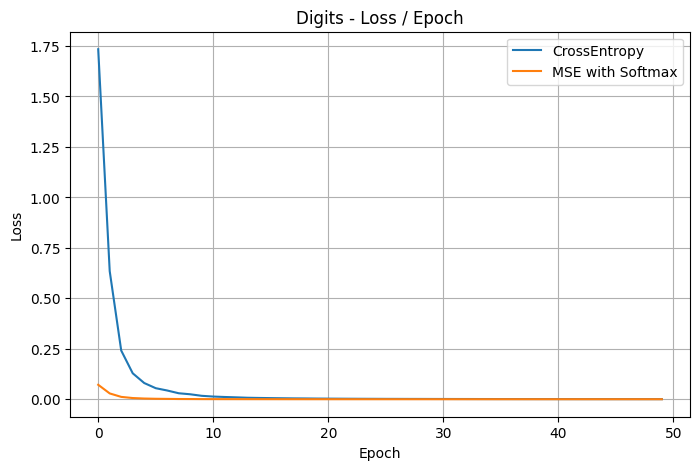

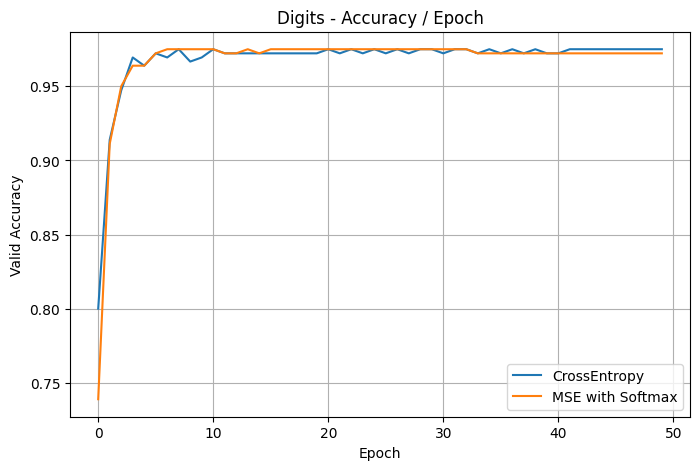

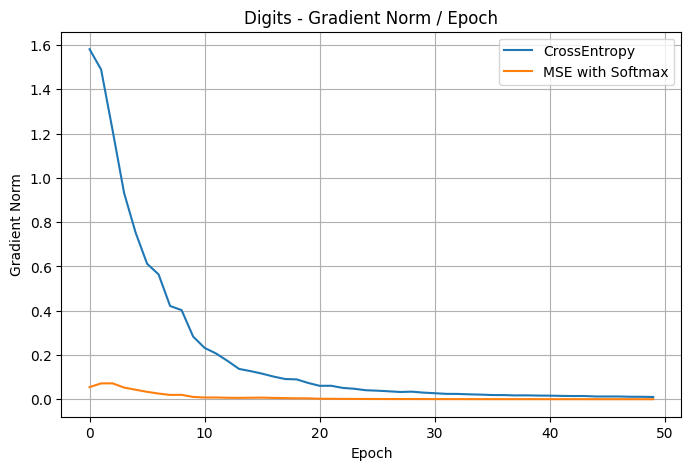

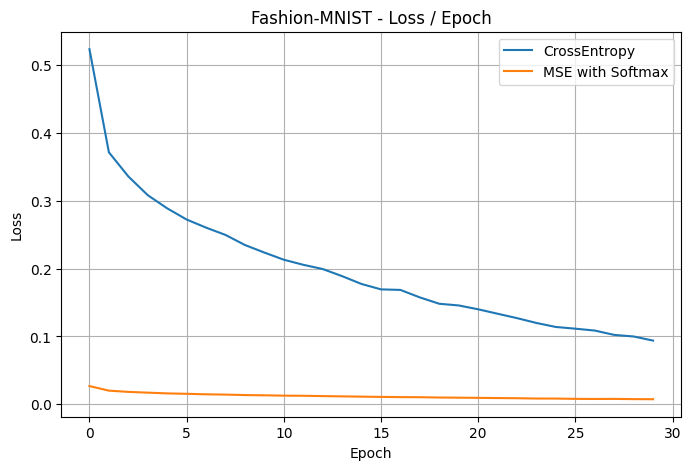

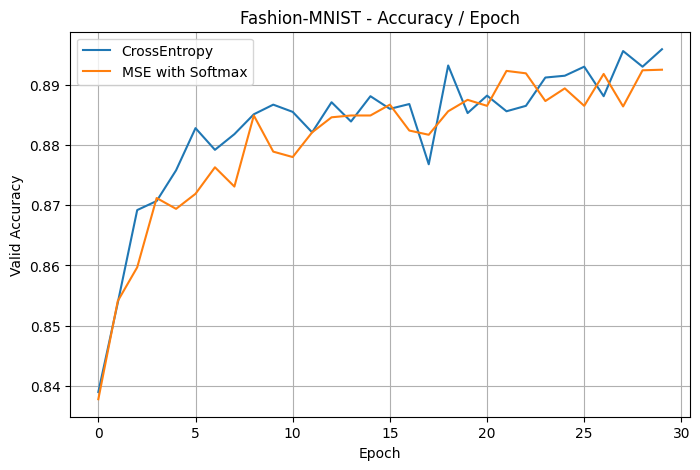

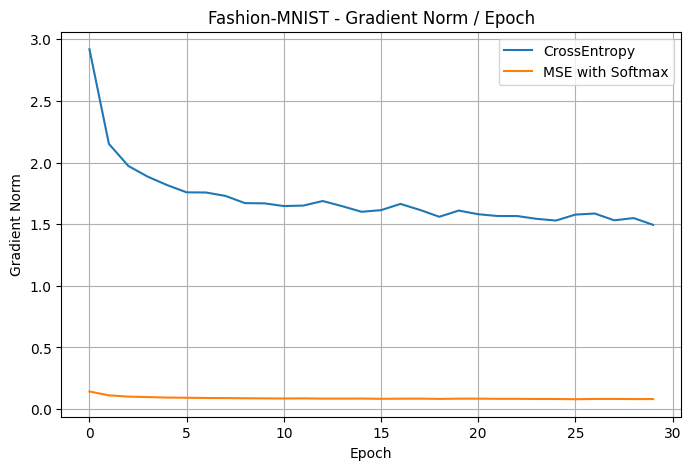

,Dataset,Loss Function,Fixed Activation,Fixed Optimizer,Learning Rate,Final Valid Accuracy,Best Valid Accuracy,Best Epoch,Minimum Loss,Final Gradient Norm,Convergence Epoch
0,Digits,CrossEntropy,relu,adam,0.001,0.975000,0.9750,8,0.000418,0.010451,4
1,Digits,MSE with Softmax,relu,adam,0.001,0.972222,0.9750,7,0.000008,0.000328,3
2,Fashion-MNIST,CrossEntropy,relu,adam,0.001,0.895900,0.8959,30,0.093845,1.494831,2
3,Fashion-MNIST,MSE with Softmax,relu,adam,0.001,0.892500,0.8925,30,0.007395,0.081796,2


In [85]:
digits_train_loader, digits_valid_loader, digits_input_size, digits_num_classes = load_digits_dataset()
fashion_train_loader, fashion_valid_loader, fashion_input_size, fashion_num_classes = load_fashion_mnist_dataset()

digits_result_A = run_experiment_A(
    dataset_name="Digits",
    train_loader=digits_train_loader,
    valid_loader=digits_valid_loader,
    input_size=digits_input_size,
    num_classes=digits_num_classes,
    epochs=50
)

fashion_result_A = run_experiment_A(
    dataset_name="Fashion-MNIST",
    train_loader=fashion_train_loader,
    valid_loader=fashion_valid_loader,
    input_size=fashion_input_size,
    num_classes=fashion_num_classes,
    epochs=30
)

plot_experiment_A(digits_result_A)
plot_experiment_A(fashion_result_A)

experiment_A_table = pd.concat([
    make_experiment_A_table(digits_result_A, threshold=0.95),
    make_experiment_A_table(fashion_result_A, threshold=0.85)
], ignore_index=True)

experiment_A_table

Experiment B | Activation: relu
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 1/300 | Loss: 0.2902 | Train Acc: 0.8669 | Valid Acc: 0.9150 | Grad Norm: 0.9048
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 2/300 | Loss: 0.1624 | Train Acc: 0.9337 | Valid Acc: 0.9175 | Grad Norm: 0.8605
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 3/300 | Loss: 0.1482 | Train Acc: 0.9450 | Valid Acc: 0.9225 | Grad Norm: 0.6379
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 4/300 | Loss: 0.1482 | Train Acc: 0.9463 | Valid Acc: 0.9150 | Grad Norm: 0.6982
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 5/300 | Loss: 0.1435 | Train Acc: 0.9531 | Valid Acc: 0.9225 | Grad Norm: 0.6526
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 6/300 | Loss: 0.1437 | Train Acc: 0.9463 | Valid Acc: 0.9225 | Grad Norm: 0.5445
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 7/300 | Loss: 0.1459 | Train Acc: 0.9506 | Valid Acc: 0.9200 | Grad Norm: 0.5848
[loss=cross_entropy, opt=adam, lr=0.01] Epoch 8/300 | Loss: 0.1489 | Train Acc:

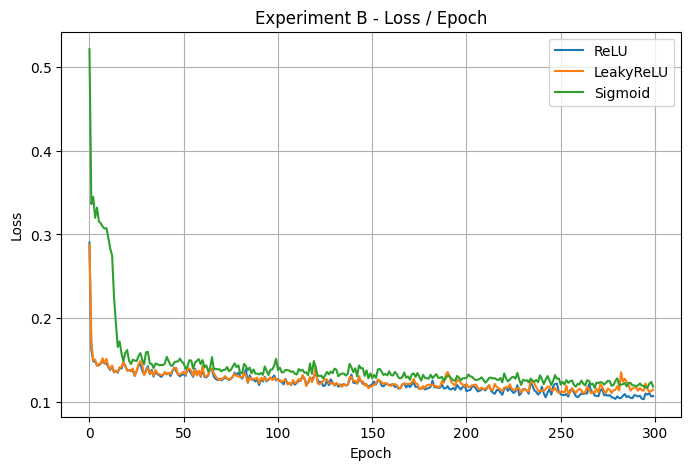

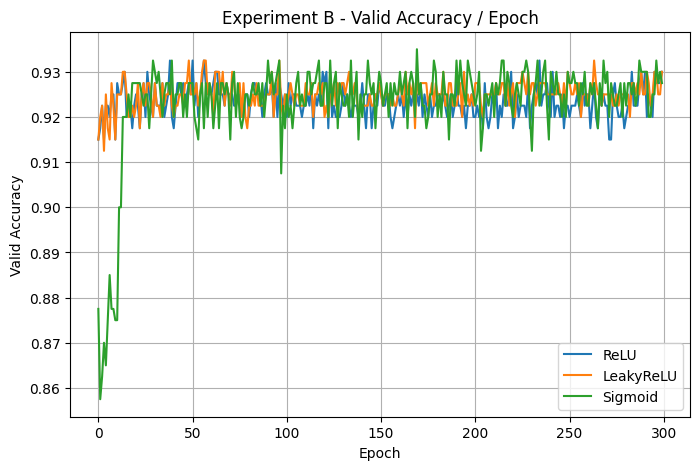

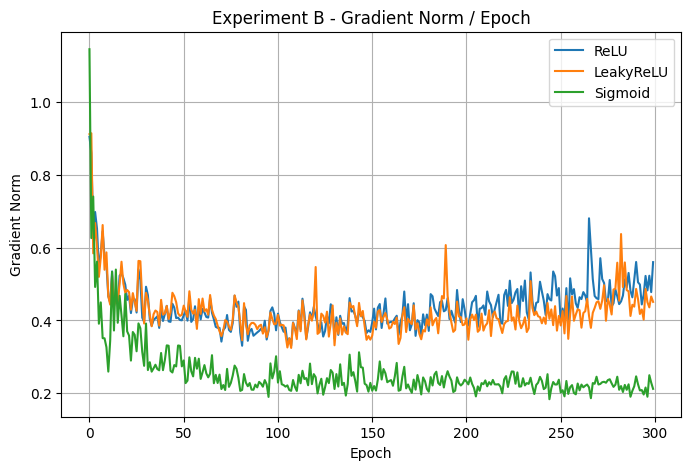

,Activation,Fixed Loss,Fixed Optimizer,Learning Rate,Layer1 Dead Ratio,Layer2 Dead Ratio,Final Valid Accuracy,Best Valid Accuracy,Best Epoch,Final Gradient Norm,Convergence Epoch
0,relu,cross_entropy,adam,0.01,0.884949,0.938477,0.9300,0.9325,39,0.560339,1
1,leaky_relu,cross_entropy,adam,0.01,0.000061,0.000000,0.9300,0.9325,49,0.451041,1
2,sigmoid,cross_entropy,adam,0.01,0.000000,0.491699,0.9275,0.9350,170,0.211926,12


In [88]:
moon_train_loader, moon_valid_loader, moon_input_size, moon_num_classes = load_moons_dataset()

result_B = run_experiment_B(
    train_loader=moon_train_loader,
    valid_loader=moon_valid_loader,
    input_size=moon_input_size,
    num_classes=moon_num_classes,
    epochs=300
)

plot_experiment_B(result_B)

experiment_B_table = make_experiment_B_table(
    result_B,
    data_loader=moon_valid_loader,
    threshold=0.90
)

experiment_B_table

Experiment C | Optimizer: sgd | LR: 0.1
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 1/50 | Loss: 2.0679 | Train Acc: 0.5261 | Valid Acc: 0.7083 | Grad Norm: 1.3880
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 2/50 | Loss: 1.3388 | Train Acc: 0.7676 | Valid Acc: 0.7944 | Grad Norm: 1.6718
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 3/50 | Loss: 0.7504 | Train Acc: 0.8566 | Valid Acc: 0.8611 | Grad Norm: 1.4579
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 4/50 | Loss: 0.4945 | Train Acc: 0.9068 | Valid Acc: 0.9139 | Grad Norm: 1.3129
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 5/50 | Loss: 0.3614 | Train Acc: 0.9318 | Valid Acc: 0.9250 | Grad Norm: 1.2141
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 6/50 | Loss: 0.2793 | Train Acc: 0.9457 | Valid Acc: 0.9389 | Grad Norm: 1.0899
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 7/50 | Loss: 0.2312 | Train Acc: 0.9534 | Valid Acc: 0.9444 | Grad Norm: 0.9970
[loss=cross_entropy, opt=sgd, lr=0.1] Epoch 8/50 | Loss: 0.1984 | Train Acc: 0.9645 | Valid 

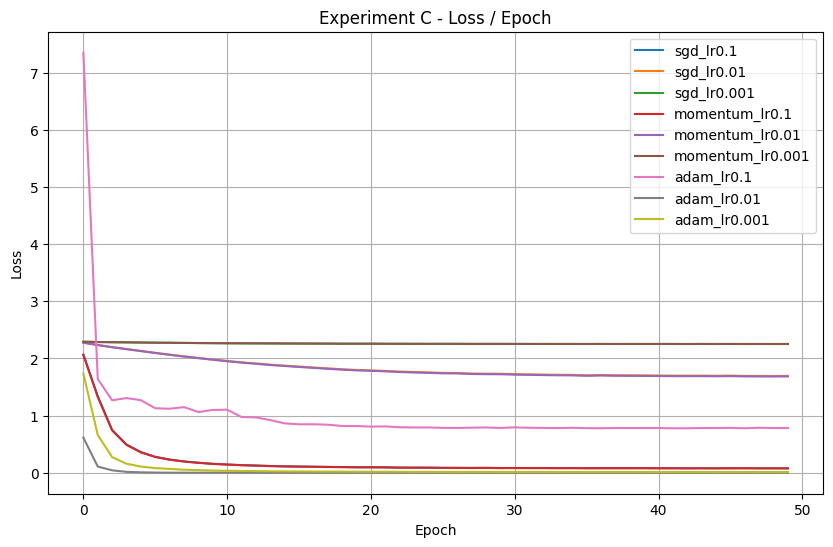

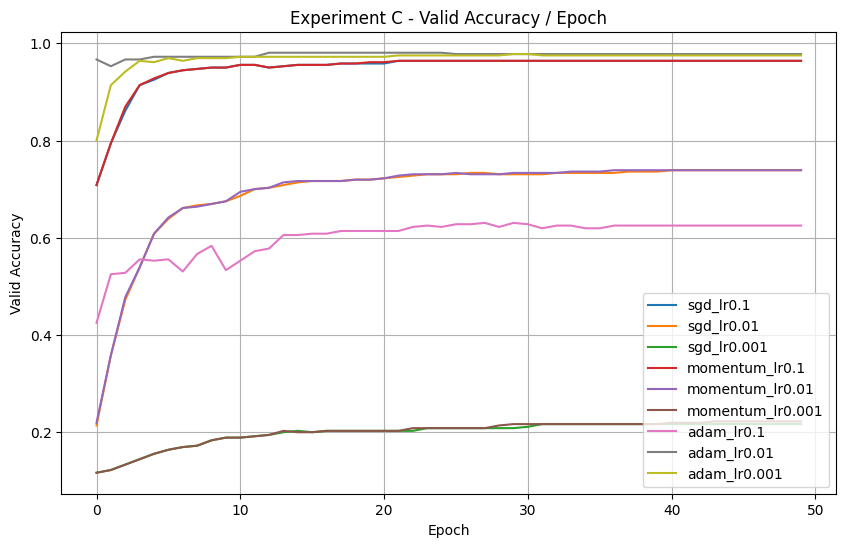

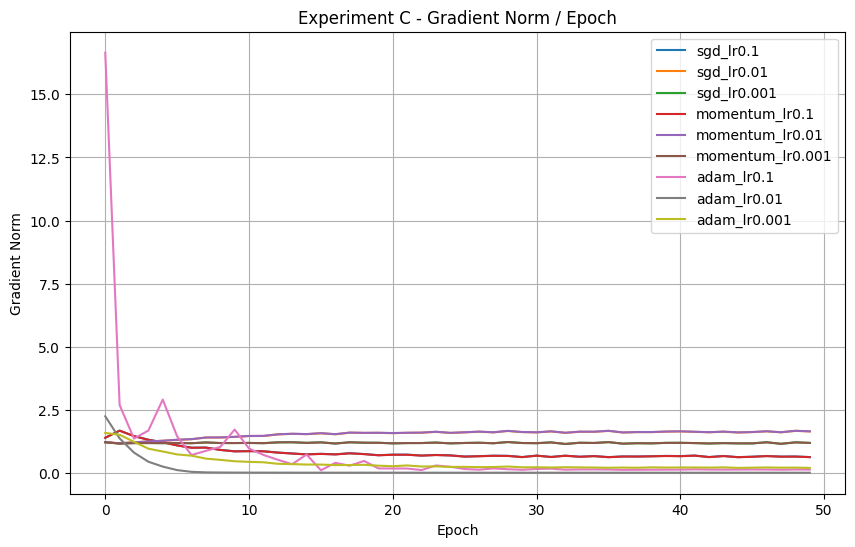

,Optimizer,Learning Rate,Fixed Activation,Fixed Loss,Scheduler,Final Valid Accuracy,Best Valid Accuracy,Best Epoch,Minimum Loss,Final Gradient Norm,Loss Stability(std last 10),Convergence Epoch
0,sgd,0.100,relu,cross_entropy,ExponentialLR(gamma=0.9),0.963889,0.963889,22,0.077395,0.624933,0.000587,9.0
1,sgd,0.010,relu,cross_entropy,ExponentialLR(gamma=0.9),0.738889,0.738889,41,1.693437,1.640551,0.002779,NaN
2,sgd,0.001,relu,cross_entropy,ExponentialLR(gamma=0.9),0.216667,0.216667,32,2.253744,1.185404,0.000293,NaN
3,momentum,0.100,relu,cross_entropy,ExponentialLR(gamma=0.9),0.963889,0.963889,22,0.076251,0.620469,0.000579,9.0
4,momentum,0.010,relu,cross_entropy,ExponentialLR(gamma=0.9),0.738889,0.738889,37,1.684419,1.644879,0.002815,NaN
5,momentum,0.001,relu,cross_entropy,ExponentialLR(gamma=0.9),0.222222,0.222222,44,2.253328,1.185430,0.000294,NaN
6,adam,0.100,relu,cross_entropy,ExponentialLR(gamma=0.9),0.625000,0.630556,28,0.777394,0.128018,0.003005,NaN
7,adam,0.010,relu,cross_entropy,ExponentialLR(gamma=0.9),0.977778,0.980556,13,0.000127,0.003789,0.000001,1.0
8,adam,0.001,relu,cross_entropy,ExponentialLR(gamma=0.9),0.975000,0.977778,30,0.011832,0.194423,0.000139,4.0


In [89]:
result_C = run_experiment_C(
    dataset_name="Digits",
    train_loader=digits_train_loader,
    valid_loader=digits_valid_loader,
    input_size=digits_input_size,
    num_classes=digits_num_classes,
    epochs=50
)

plot_experiment_C(result_C)

experiment_C_table = make_experiment_C_table(
    result_C,
    threshold=0.95
)

experiment_C_table